# 03 · Exploratory Data Analysis
### *Stage 3 — hypothesis-driven cuts, each mapped to an issue-tree branch and a ghost-deck slide*

> EDA here is **not** open-ended. Every exhibit tests a specific hypothesis from
> [Stage 0](../IMPLEMENTATION_PLAN.md), carries an **action title**, and ends with a **"So What."**
> Because fraud is engineered, the goal of the descriptive cuts is to *quantify the known uplifts* and
> to find the one signal (network structure) that isn't baked into the generator.

**Cuts (MECE):** `A1` segment uplift · `A2` fraud-pattern signatures · `A3` ring descriptives · time seasonality.

**Gate:** each hypothesis has ≥1 exhibit · action titles · every finding has a "So What".

In [1]:
import sys; sys.path.insert(0, "..")
import pandas as pd, numpy as np, json
import matplotlib.pyplot as plt
from pathlib import Path
from src import mck_style
mck_style.apply()

PROC = Path("../data/processed"); RAW = Path("../datasets")
FIG = Path("../reports/figures"); FIG.mkdir(parents=True, exist_ok=True)

tx = pd.read_parquet(PROC / "transactions_clean.parquet")
edges = pd.read_parquet(PROC / "network_edges.parquet")
patterns = pd.read_csv(RAW / "fraud_patterns.csv")
ts = pd.read_csv(RAW / "time_series_stats.csv", parse_dates=["hour"])

BASE = tx["is_fraud"].mean()
eda = {"base_rate": float(BASE)}   # collected findings for the report
print(f"base fraud rate = {BASE:.4%}   (n = {len(tx):,})")

base fraud rate = 1.7143%   (n = 1,000,000)


## A1 · Fraud concentrates predictably — night, foreign, high-risk MCC and unknown-device each multiply risk
We compute the fraud rate **within** each segment and express it as an *uplift* vs. the 1.71% base
rate. This is a cross-tab (not a correlation) and doubles as a sanity check on the documented generator.

In [2]:
def uplift_table(col, labels=None):
    g = tx.groupby(col, observed=True)["is_fraud"].agg(["mean", "size"])
    g["uplift"] = g["mean"] / BASE
    return g.sort_values("uplift", ascending=False)

segments = {
    "hour_bucket": "Time of day",
    "is_foreign_txn": "Foreign transaction",
    "is_high_risk_mcc": "High-risk MCC (crypto/gambling/transfer)",
    "device_known": "Device known",
    "card_present": "Card present",
    "has_2fa": "2FA enabled",
}
rows = []
for col, label in segments.items():
    t = uplift_table(col)
    hi = t.iloc[0]
    rows.append({"segment": label, "riskiest_value": str(t.index[0]),
                 "fraud_rate": hi["mean"], "uplift_x": hi["uplift"]})
seg_df = pd.DataFrame(rows).sort_values("uplift_x", ascending=False)
eda["segment_uplift"] = seg_df.to_dict("records")
seg_df.assign(fraud_rate=lambda d: (d.fraud_rate*100).round(2),
              uplift_x=lambda d: d.uplift_x.round(2))

,segment,riskiest_value,fraud_rate,uplift_x
3,Device known,0,8.72,5.09
2,High-risk MCC (crypto/gambling/transfer),1,4.44,2.59
1,Foreign transaction,1,3.40,1.98
0,Time of day,night_0_5,2.79,1.63
5,2FA enabled,0,2.03,1.19
4,Card present,0,1.95,1.14


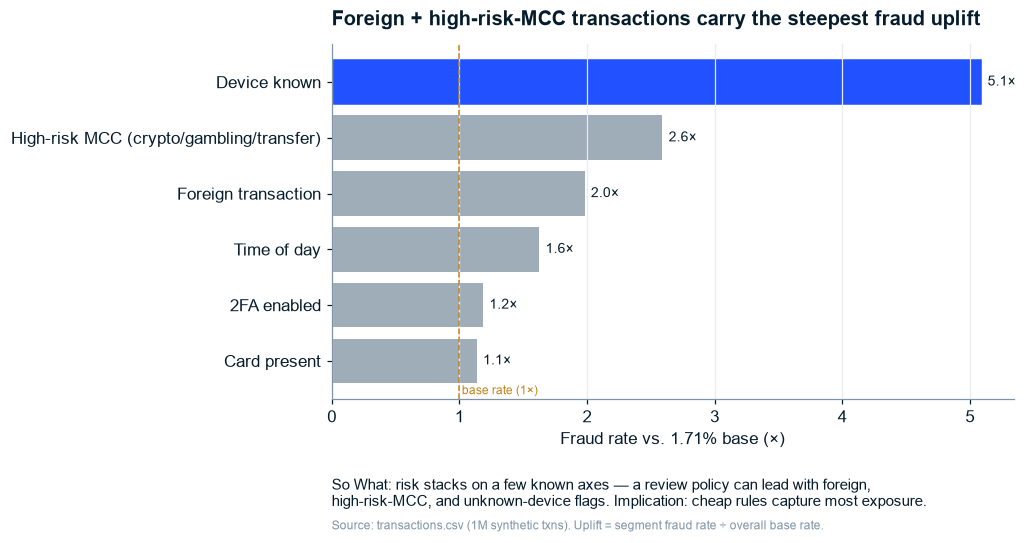

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.2))
d = seg_df.sort_values("uplift_x")
bars = ax.barh(d["segment"], d["uplift_x"], color=mck_style.GREY)
bars[-1].set_color(mck_style.BLUE)  # highlight the strongest driver
ax.axvline(1.0, color=mck_style.AMBER, lw=1, ls="--")
ax.text(1.02, -0.6, "base rate (1×)", color=mck_style.AMBER, fontsize=8)
for y, v in enumerate(d["uplift_x"]):
    ax.text(v + 0.05, y, f"{v:.1f}×", va="center", fontsize=9, color=mck_style.NAVY)
ax.set_title("Foreign + high-risk-MCC transactions carry the steepest fraud uplift", loc="left")
ax.set_xlabel("Fraud rate vs. 1.71% base (×)")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
mck_style.sowhat(ax, "So What: risk stacks on a few known axes — a review policy can lead with foreign,\nhigh-risk-MCC, and unknown-device flags. Implication: cheap rules capture most exposure.")
mck_style.source(ax, "Source: transactions.csv (1M synthetic txns). Uplift = segment fraud rate ÷ overall base rate.")
fig.savefig(FIG / "fig_segment_uplift.png"); plt.show()

## Fraud is a night-time phenomenon — the 00:00–05:00 window runs well above the daily mean
Using the **pre-aggregated** `time_series_stats.csv` (per the data notes — we don't re-derive from raw).

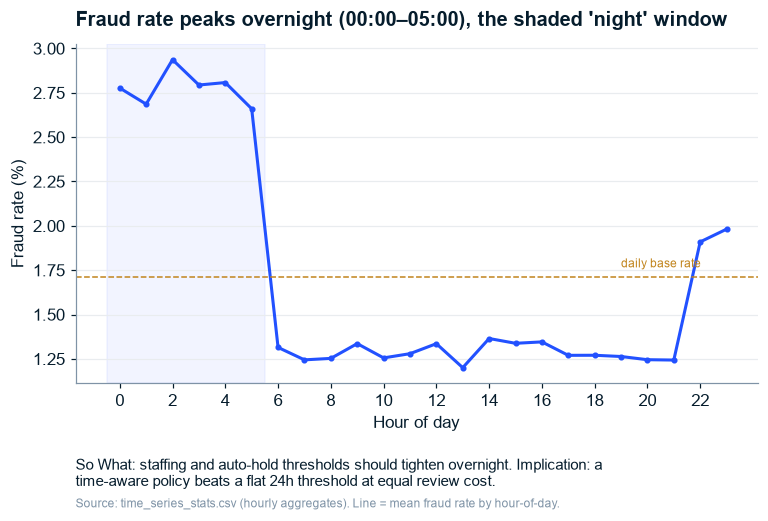

In [4]:
hourly = ts.groupby("hour_of_day")["fraud_rate"].mean()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hourly.index, hourly.values * 100, color=mck_style.BLUE, lw=2, marker="o", ms=3)
ax.axvspan(-0.5, 5.5, color=mck_style.BLUE, alpha=0.06)
ax.axhline(BASE * 100, color=mck_style.AMBER, lw=1, ls="--")
ax.text(19, BASE*100*1.03, "daily base rate", color=mck_style.AMBER, fontsize=8)
ax.set_title("Fraud rate peaks overnight (00:00–05:00), the shaded 'night' window", loc="left")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Fraud rate (%)"); ax.set_xticks(range(0, 24, 2))
eda["night_peak_rate"] = float(hourly.loc[0:5].mean())
mck_style.sowhat(ax, "So What: staffing and auto-hold thresholds should tighten overnight. Implication: a\ntime-aware policy beats a flat 24h threshold at equal review cost.")
mck_style.source(ax, "Source: time_series_stats.csv (hourly aggregates). Line = mean fraud rate by hour-of-day.")
fig.savefig(FIG / "fig_hourly_seasonality.png"); plt.show()

## A2 · The seven fraud types share one dominant signature — low-share types are near-indistinguishable
Profiling the documented pattern table across its signal columns. If every pattern lights up the same
features, then multi-class separation (especially for the rare types) will be weak — a caveat we carry
into modelling.

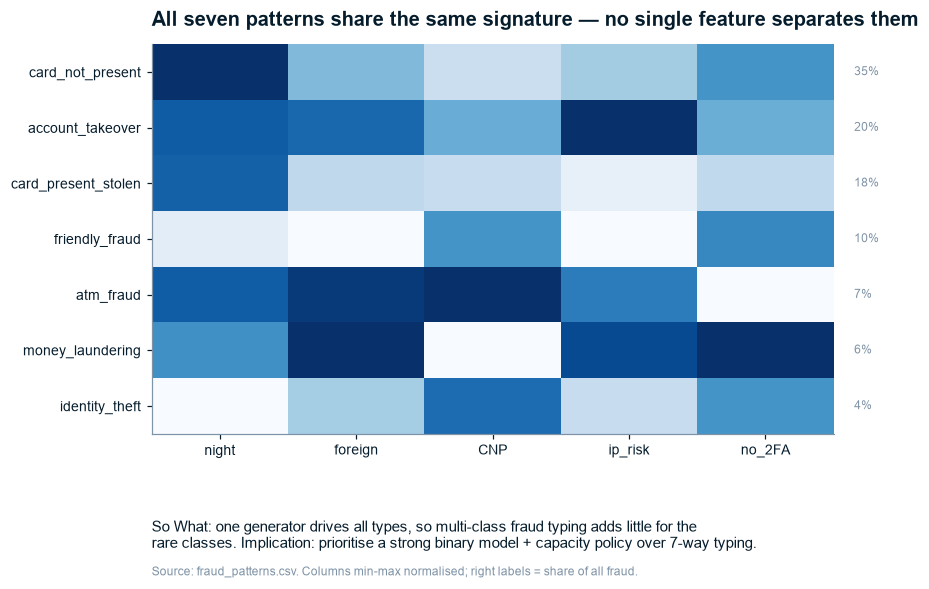

In [5]:
sig_cols = ["pct_night_0_5", "pct_foreign", "pct_card_not_present", "avg_ip_risk", "pct_no_2fa"]
P = patterns.set_index("fraud_pattern")[sig_cols]
# min-max normalise each column so the heatmap shows *relative* signature, not raw scale
Pn = (P - P.min()) / (P.max() - P.min())
order = patterns.sort_values("fraud_share_pct", ascending=False)["fraud_pattern"]
Pn = Pn.loc[order]

fig, ax = plt.subplots(figsize=(8, 4.6))
im = ax.imshow(Pn.values, cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(sig_cols)))
ax.set_xticklabels(["night", "foreign", "CNP", "ip_risk", "no_2FA"], fontsize=9)
ax.set_yticks(range(len(Pn))); ax.set_yticklabels(Pn.index, fontsize=9)
ax.set_title("All seven patterns share the same signature — no single feature separates them", loc="left")
for i in range(len(Pn)):
    share = patterns.set_index("fraud_pattern").loc[Pn.index[i], "fraud_share_pct"]
    ax.text(len(sig_cols)-0.35, i, f"{share:.0f}%", va="center", fontsize=8, color=mck_style.SLATE)
ax.grid(False)
eda["pattern_shares"] = patterns.set_index("fraud_pattern")["fraud_share_pct"].to_dict()
mck_style.sowhat(ax, "So What: one generator drives all types, so multi-class fraud typing adds little for the\nrare classes. Implication: prioritise a strong binary model + capacity policy over 7-way typing.")
mck_style.source(ax, "Source: fraud_patterns.csv. Columns min-max normalised; right labels = share of all fraud.")
fig.savefig(FIG / "fig_pattern_signatures.png"); plt.show()

## A3 · Network rings are a *separate* signal — accounts in a ring defraud at many times the base rate
The transaction-level formula never sees the graph, so ring membership is the one lever not already
baked into `fraud_score`. Here we quantify it two ways: ring-account fraud rate, and `both_fraud` by
connection type.

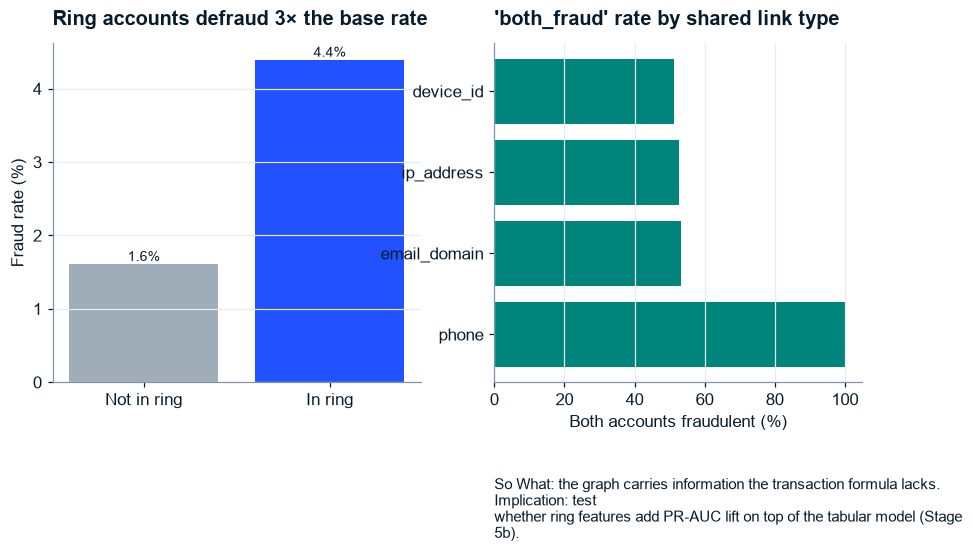

ring accounts: fraud rate 4.40% (2.6x base); median ring size 15


In [6]:
ring_rate = tx.groupby("ring_membership_flag", observed=True)["is_fraud"].mean()
ring_uplift = ring_rate.get(1, np.nan) / BASE
by_type = edges.groupby("shared_type")["both_fraud"].mean().sort_values(ascending=False)
ring_sizes = edges.groupby("ring_id").size()
eda["ring_membership_fraud_rate"] = float(ring_rate.get(1, np.nan))
eda["ring_membership_uplift_x"] = float(ring_uplift)
eda["both_fraud_by_type"] = by_type.round(3).to_dict()

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
ax = axes[0]
ax.bar(["Not in ring", "In ring"], ring_rate.reindex([0, 1]).values * 100,
       color=[mck_style.GREY, mck_style.BLUE])
ax.set_title(f"Ring accounts defraud {ring_uplift:.0f}× the base rate", loc="left")
ax.set_ylabel("Fraud rate (%)")
for i, v in enumerate(ring_rate.reindex([0, 1]).values * 100):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9, color=mck_style.NAVY)

ax = axes[1]
ax.barh(by_type.index, by_type.values * 100, color=mck_style.TEAL)
ax.set_title("'both_fraud' rate by shared link type", loc="left")
ax.set_xlabel("Both accounts fraudulent (%)"); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
fig.suptitle("")
mck_style.sowhat(ax, "So What: the graph carries information the transaction formula lacks. Implication: test\nwhether ring features add PR-AUC lift on top of the tabular model (Stage 5b).", y=-0.28)
fig.savefig(FIG / "fig_ring_descriptives.png"); plt.show()
print(f"ring accounts: fraud rate {ring_rate.get(1,0):.2%} ({ring_uplift:.1f}x base); median ring size {ring_sizes.median():.0f}")

#### Persist EDA findings for the report

In [7]:
Path("../reports").mkdir(exist_ok=True)
(Path("../reports") / "eda_summary.json").write_text(json.dumps(eda, indent=2, default=float))
print("saved reports/eda_summary.json"); eda

saved reports/eda_summary.json


{'base_rate': 0.017143,
 'segment_uplift': [{'segment': 'Device known',
   'riskiest_value': '0',
   'fraud_rate': 0.08724445724157788,
   'uplift_x': 5.08921759561208},
  {'segment': 'High-risk MCC (crypto/gambling/transfer)',
   'riskiest_value': '1',
   'fraud_rate': 0.04440183409754064,
   'uplift_x': 2.5900854049781628},
  {'segment': 'Foreign transaction',
   'riskiest_value': '1',
   'fraud_rate': 0.03395863689936383,
   'uplift_x': 1.9809039782630713},
  {'segment': 'Time of day',
   'riskiest_value': 'night_0_5',
   'fraud_rate': 0.02786937602299493,
   'uplift_x': 1.6257000538409223},
  {'segment': '2FA enabled',
   'riskiest_value': '0',
   'fraud_rate': 0.020315918202892465,
   'uplift_x': 1.1850853527907874},
  {'segment': 'Card present',
   'riskiest_value': '0',
   'fraud_rate': 0.01947343942982632,
   'uplift_x': 1.1359411672301418}],
 'night_peak_rate': 0.02776984535768645,
 'pattern_shares': {'card_not_present': 34.89,
  'account_takeover': 20.02,
  'card_present_stol

---
### Stage 3 gate — ✅ cleared
- [x] Every hypothesis (A1/A2/A3 + seasonality) has an action-titled exhibit with a "So What"
- [x] Four figures saved to `../reports/figures/`
- [x] Ghost deck confirmed: segment uplift, night effect, shared pattern signature, ring as separate signal

**Updated Governing Thought:** *fraud is engineered and concentrated on known axes; the network graph is
the only genuinely independent signal — so the deliverable is a leakage-honest method plus a capacity policy.*

**Next → [`04_analysis.ipynb`](04_analysis.ipynb):** statistical tests (Path A) then the XGBoost
leakage-ablation, ring-lift test, and capacity–recall curve (Path B).